In [ ]:
# Check GPU availability and install latest Ultralytics package
!nvidia-smi
!pip install -q ultralytics

Tue Aug 18 16:41:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import files
import zipfile
import os

# Prompt file upload from local machine
print("Please select your nepali_dal_bhat_dataset.zip file:")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

# Extract directly into Colab runtime storage
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content')

print("Dataset uploaded and extracted successfully to /content!")

Please select your nepali_dal_bhat_dataset.zip file:


Saving final_yolo_model_dataset.zip to final_yolo_model_dataset.zip
Dataset uploaded and extracted successfully to /content!


In [ ]:
import yaml

# Overwrite data.yaml in the correct dataset folder
yaml_content = {
    'path': '/content/final_yolo_model_dataset',
    'train': 'images/train',
    'val': 'images/val',
    'names': {
        0: 'bhat',
        1: 'dal',
        2: 'sabji'
    }
}

with open('/content/final_yolo_model_dataset/data.yaml', 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print("data.yaml successfully created in /content/final_yolo_model_dataset!")

data.yaml successfully created in /content/final_yolo_model_dataset!


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n-seg.pt")

results = model.train(
    data="/content/final_yolo_model_dataset/data.yaml", # Updated path here
    task="segment",
    epochs=100,
    imgsz=640,
    batch=16,
    workers=8,
    patience=30,

    # Optimization
    optimizer="AdamW",
    lr0=0.002,
    lrf=0.01,
    cos_lr=True,
    weight_decay=0.0005,

    # Augmentations
    augment=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0001,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,

    project="/content/runs/segment",
    name="nepali_plate_final_run",
    exist_ok=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/final_yolo_model_dataset/data.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=nepali_plate_f

In [ ]:
from google.colab import files

files.download('/content/runs/segment/nepali_plate_final_run/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving testing image 3.jpeg to testing image 3.jpeg

image 1/1 /content/testing image 3.jpeg: 544x640 1 bhat, 2 dals, 2 sabjis, 9.4ms
Speed: 3.1ms preprocess, 9.4ms inference, 1.9ms postprocess per image at shape (1, 3, 544, 640)


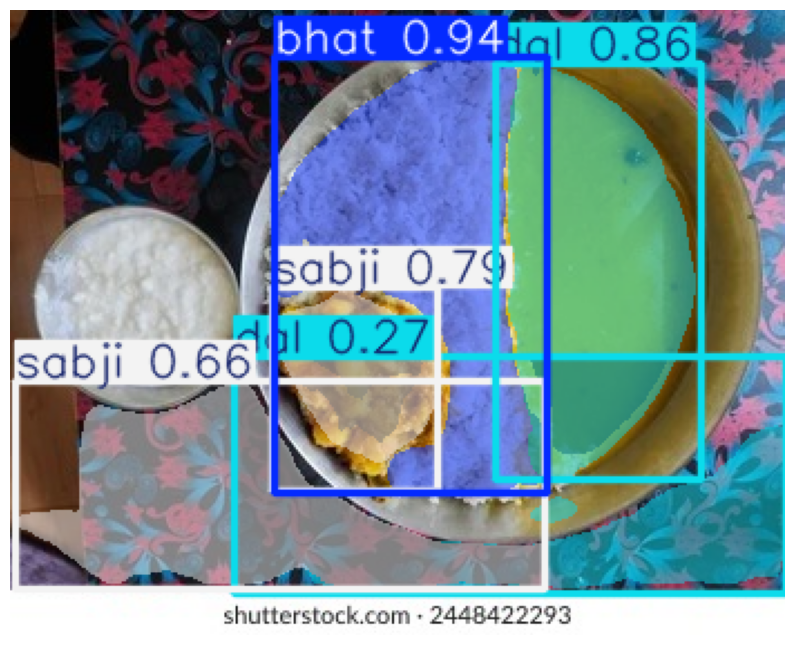

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load your fine-tuned segmentation model
model = YOLO('/content/runs/segment/nepali_plate_final_run/weights/best.pt')

# 2. Upload an image from your computer
uploaded = files.upload()

# 3. Predict on the uploaded image
for file_name in uploaded.keys():
    # Run inference with a confidence threshold
    results = model.predict(source=file_name, conf=0.25)

    # Render the segmentation masks and bounding boxes onto the image
    res_plotted = results[0].plot()

    # Convert BGR (OpenCV format) to RGB for Matplotlib display
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    # Display the result
    plt.figure(figsize=(10, 10))
    plt.imshow(res_rgb)
    plt.axis('off')
    plt.show()

In [ ]:
import cv2
import numpy as np

# 1. Reference dimensions (assuming standard plate diameter = 28 cm)
KNOWN_PLATE_DIAMETER_CM = 28.0

# 2. Food physical properties (Density in g/cm3, Estimated average height in cm)
FOOD_PROPERTIES = {
    'bhat':  {'density': 0.75, 'avg_height_cm': 3.5, 'shape': 'dome'},
    'dal':   {'density': 1.05, 'avg_height_cm': 4.0, 'shape': 'cylinder'},
    'sabji': {'density': 0.90, 'avg_height_cm': 2.0, 'shape': 'flat'}
}

results = model.predict(source="6a449b8a-261.jpg", conf=0.25)
res = results[0]

# Estimate pixel scale using bounding box width/height of full plate or largest object
# For best results, detect the plate rim. Here we approximate scale from image dimensions:
img_h, img_w = res.orig_shape
plate_pixel_diameter = min(img_h, img_w) * 0.85 # Estimated plate pixel width
cm_per_pixel = KNOWN_PLATE_DIAMETER_CM / plate_pixel_diameter
sq_cm_per_pixel = cm_per_pixel ** 2

if res.masks is not None:
    masks = res.masks.data.cpu().numpy()
    classes = res.boxes.cls.cpu().numpy()
    names = res.names

    total_weights = {}

    for i, mask in enumerate(masks):
        cls_name = names[int(classes[i])]

        # Resize mask to original image size
        mask_resized = cv2.resize(mask, (img_w, img_h)) > 0.5
        pixel_area = np.sum(mask_resized)
        area_sq_cm = pixel_area * sq_cm_per_pixel

        # Retrieve density and height
        prop = FOOD_PROPERTIES.get(cls_name, {'density': 0.85, 'avg_height_cm': 2.0, 'shape': 'flat'})

        # Calculate volume based on shape approximation
        if prop['shape'] == 'dome':
            # Hemisphere/Dome approximation: V = 0.6 * Area * Height
            volume_cm3 = 0.6 * area_sq_cm * prop['avg_height_cm']
        else:
            volume_cm3 = area_sq_cm * prop['avg_height_cm']

        weight_grams = volume_cm3 * prop['density']

        total_weights[cls_name] = total_weights.get(cls_name, 0) + weight_grams

    # Print Estimated Results
    print("--- Estimated Food Quantities ---")
    for item, weight in total_weights.items():
        print(f"{item.capitalize()}: ~{weight:.1f} grams")


image 1/1 /content/6a449b8a-261.jpg: 448x640 1 bhat, 1 dal, 3 sabjis, 14.6ms
Speed: 3.3ms preprocess, 14.6ms inference, 2.5ms postprocess per image at shape (1, 3, 448, 640)
--- Estimated Food Quantities ---
Bhat: ~155.5 grams
Dal: ~284.8 grams
Sabji: ~137.2 grams


In [ ]:
import os

# Path to the best trained weights
best_model_path = "/content/runs/segment/nepali_plate_final_run/weights/best.pt"

if os.path.exists(best_model_path):
    size_mb = os.path.getsize(best_model_path) / (1024 * 1024)
    print(f"Final Model Saved: {best_model_path}")
    print(f"Model File Size: {size_mb:.2f} MB")
else:
    print("Training finished. Check runs directory for output.")